Banco de dados cotações

C:\Users\mateuslm\AppData\Local\Temp\ipykernel_16252\3403239908.py:489: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfquotes_ult_rev_rep_email['Próximo followup'] = pd.to_datetime(
C:\Users\mateuslm\AppData\Local\Temp\ipykernel_16252\3403239908.py:492: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfquotes_ult_rev_rep_email['Data de fechamento esperada'] = pd.to_datetime(
C:\Users\mateuslm\AppData\Local\Temp\ipykernel_16252\3403239908.py:495: SettingWithCopyWarning: 
A value is trying to be set on a copy 

Prévia do e-mail salva em: email_preview_10001.html
Erro ao anexar o arquivo: [Errno 2] No such file or directory: 'RAZAO SOCIAL 1/2026-02-11.xlsx'


gaierror: [Errno 11001] getaddrinfo failed

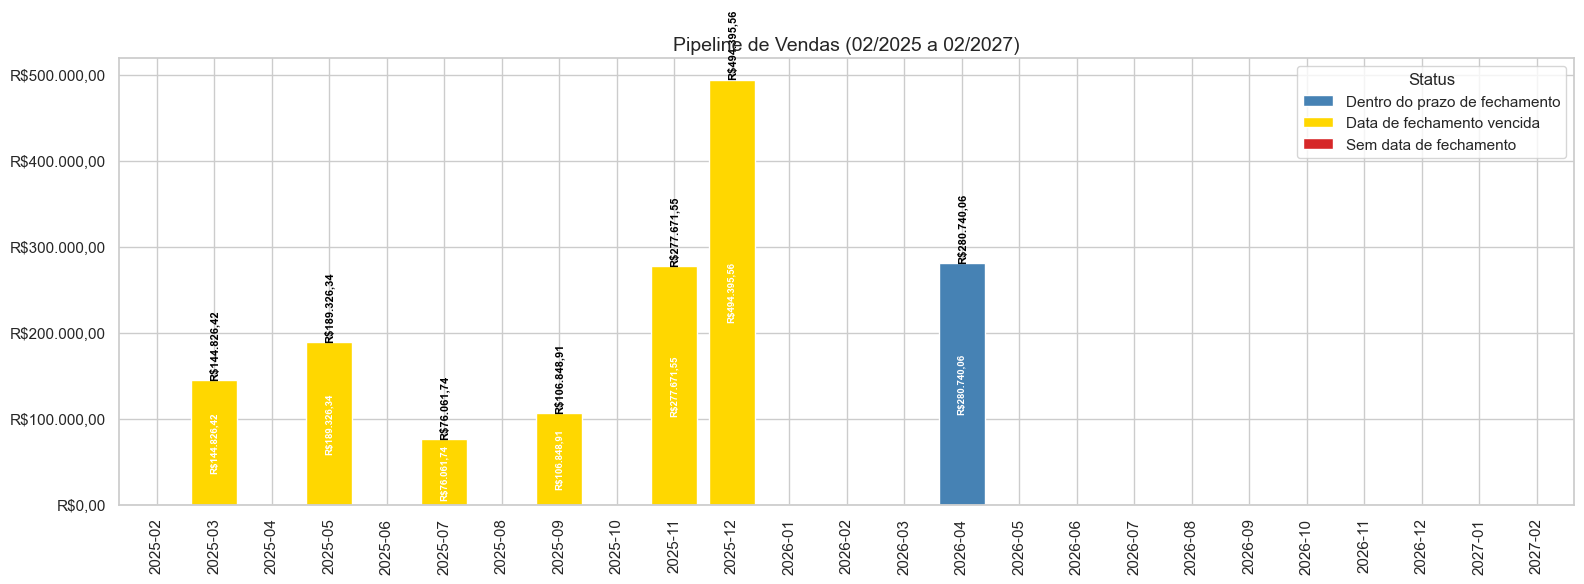

In [21]:
import time
start = time.process_time()
import pandas as pd
pd.options.display.float_format = '{:,}'.format
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap
import sys
import os
import base64
from io import BytesIO

# Gráficos
import seaborn as sns
import matplotlib.ticker as ticker

# Bibliotecas para envio de e-mail
import smtplib
from email.message import EmailMessage
from email.headerregistry import Address
from email.utils import make_msgid

# CAMINHO GENÉRICO
sys.path.append(os.path.abspath('C:/Users/usuario/Projetos/Arquivos_PY'))

# funcoes (externo)
import functions as fc

# =====================================================
# DADOS FICTÍCIOS / GENÉRICOS PARA USO PÚBLICO
# Substitui: contatos, customers_info, reps, quotes
# =====================================================

np.random.seed(42)  # para reprodutibilidade

# =====================================================
# 1) CONTATOS (contatos.df_contatos)
# =====================================================

engenheiros = [f'ENGENHEIRO {i}' for i in range(1, 4)]
analistas = [f'ANALISTA {i}' for i in range(1, 4)]

contatos_df = pd.DataFrame({
    "Cargo": (["Engenheiro de aplicação"] * len(engenheiros)) + (["Analista de vendas"] * len(analistas)),
    "Nome": engenheiros + analistas,
    "E-mail": [f"engenheiro{i}@empresa.com" for i in range(1, 4)] +
              [f"analista{i}@empresa.com" for i in range(1, 4)]
})

class contatos:
    df_contatos = contatos_df


# =====================================================
# 2) REPRESENTANTES (reps.df_reps)
# =====================================================

num_reps = 5
codigos_reps = [10000 + i for i in range(1, num_reps + 1)]
nomes_reps = [f"REPRESENTANTE {i}" for i in range(1, num_reps + 1)]

reps_df = pd.DataFrame({
    "Código ": codigos_reps,
    "Razão Social": [f"RAZAO SOCIAL {i}" for i in range(1, num_reps + 1)],
    "CNPJ": [f"00.000.000/000{i:02d}-00" for i in range(1, num_reps + 1)],
    "Atendimento": np.random.choice(["GRUPO A", "GRUPO B", "GRUPO C"], size=num_reps),
    "Nome do Representante": nomes_reps,
    "Endereço completo": [f"RUA EXEMPLO {i}, 123 - BAIRRO X" for i in range(1, num_reps + 1)],
    "Cidade": [f"CIDADE {chr(64+i)}" for i in range(1, num_reps + 1)],
    "UF": np.random.choice(["SP", "RJ", "MG", "RS", "PR"], size=num_reps),
    "CEP": [f"00000-0{i:02d}" for i in range(1, num_reps + 1)],
    "Telefone comercial": [f"11-3000-30{i:02d}" for i in range(1, num_reps + 1)],
    "Celular": [f"11-90000-00{i:02d}" for i in range(1, num_reps + 1)],
    "E-Mail": [f"representante{i}@empresa.com" for i in range(1, num_reps + 1)],
    "E-mail acompanhamento": [f"representante{i}@empresa.com" for i in range(1, num_reps + 1)],
    "e-mail Particular": [f"particular{i}@email.com" for i in range(1, num_reps + 1)],
    "Cod do Reps como CLIENTE": [500000 + i for i in range(1, num_reps + 1)],
    "Aniversário": [f"{i:02d}/01" for i in range(1, num_reps + 1)],
    "Tipo de Item": ["Item"] * num_reps,
    "Caminho": ["caminho/ficticio"] * num_reps,
    "Primeiro nome": [f"NOME{i}" for i in range(1, num_reps + 1)],
})

class reps:
    df_reps = reps_df


# =====================================================
# 3) CUSTOMERS_INFO (customers_info.df_customers_info)
# =====================================================

num_clients = 20
codigos_clientes = [700000 + i for i in range(1, num_clients + 1)]
clientes = [f"CLIENTE {chr(64 + ((i - 1) % 26) + 1)}" for i in range(1, num_clients + 1)]
segmentos = ["SEGMENTO A", "SEGMENTO B", "SEGMENTO C"]
estados = ["ESTADO A", "ESTADO B", "ESTADO C"]
cidades = [f"CIDADE {chr(64 + ((i - 1) % 26) + 1)}" for i in range(1, num_clients + 1)]

# mapeia código representante para nome (consistência com reps_df)
map_rep_nome = dict(zip(codigos_reps, nomes_reps))
codigos_rep_clientes = np.random.choice(codigos_reps, size=num_clients)
nomes_rep_clientes = [map_rep_nome[c] for c in codigos_rep_clientes]

customers_info_df = pd.DataFrame({
    "Código cliente": codigos_clientes,
    "Cliente": clientes,
    "Pai financeiro": [np.nan] * num_clients,
    "Segmento": np.random.choice(segmentos, size=num_clients),
    "Engenheiro de aplicação": np.random.choice(engenheiros, size=num_clients),
    "Analista de vendas": np.random.choice(analistas, size=num_clients),
    # DESCONTOS APENAS COM PERCENTUAL (SEM "CAT. A / CAT. B / ...")
    "Cat. de desconto cadastro": np.random.choice(
        ["10%", "15%", "20%"], size=num_clients
    ),
    "Código representante": codigos_rep_clientes,
    "Representante": nomes_rep_clientes,
    "Código organização de vendas": np.random.choice(["1001", "1004", "1019"], size=num_clients),
    "Descrição Code Setor 4": [np.nan] * num_clients,
    "Estado": np.random.choice(estados, size=num_clients),
    "Cidade": cidades,
})

class customers_info:
    df_customers_info = customers_info_df


# =====================================================
# 4) QUOTES (quotes)
# =====================================================

num_quotes = 100

# datas de criação aleatórias nos últimos 2 anos
base_date = datetime(2024, 1, 1)
datas_criacao = [base_date + timedelta(days=int(d)) for d in np.random.randint(0, 365*2, size=num_quotes)]
datas_submissao = [d + timedelta(days=np.random.randint(0, 10)) for d in datas_criacao]
datas_followup = [d + timedelta(days=np.random.randint(5, 60)) for d in datas_criacao]
datas_fechamento_esp = [d + timedelta(days=np.random.randint(30, 180)) for d in datas_criacao]
datas_fechamento = [d + timedelta(days=np.random.randint(30, 200)) for d in datas_criacao]

status_possiveis = [
    "underApprovalByCustomer",
    "expired",
    "underApprovalByWEG",
    "rejected",
    "concluded"
]

sales_orgs = ["SO1", "SO2"]
dist_channels = ["ONLINE", "OFFLINE"]

# amostras de clientes e reps já criados
cod_clientes_sample = np.random.choice(codigos_clientes, size=num_quotes)
clientes_sample = [
    customers_info_df.loc[customers_info_df["Código cliente"] == c, "Cliente"].iloc[0]
    for c in cod_clientes_sample
]
cidades_sample = [
    customers_info_df.loc[customers_info_df["Código cliente"] == c, "Cidade"].iloc[0]
    for c in cod_clientes_sample
]
estados_sample = [
    customers_info_df.loc[customers_info_df["Código cliente"] == c, "Estado"].iloc[0]
    for c in cod_clientes_sample
]
cod_org_vendas_sample = [
    customers_info_df.loc[customers_info_df["Código cliente"] == c, "Código organização de vendas"].iloc[0]
    for c in cod_clientes_sample
]

cod_reps_sample = np.random.choice(codigos_reps, size=num_quotes)
representantes_sample = [map_rep_nome[c] for c in cod_reps_sample]

cotacoes_ids = [f"{i:09d}" for i in np.random.randint(1, 999999999, size=num_quotes)]
revisoes = np.random.randint(0, 4, size=num_quotes)
precos = np.round(np.random.uniform(50000, 300000, size=num_quotes), 2)
quantidades = np.random.randint(1, 5, size=num_quotes)

produtos = [f"PRODUTO {chr(65 + (i % 5))}" for i in range(num_quotes)]
descricoes = [f"DESCRIÇÃO PRODUTO {chr(65 + (i % 5))}" for i in range(num_quotes)]

quotes = pd.DataFrame({
    "SALES_ORG": np.random.choice(sales_orgs, size=num_quotes),
    "Cotação": cotacoes_ids,
    "Revisão": revisoes,
    "Data de criação": [d.strftime("%d/%m/%y") for d in datas_criacao],
    "Data de submissão": [d.strftime("%d/%m/%y") for d in datas_submissao],
    "QUOTE_REQUEST_DATE": [d.strftime("%d/%m/%y") for d in datas_submissao],
    "Escritório de vendas": np.random.choice(["ESCRITORIO A", "ESCRITORIO B"], size=num_quotes),
    "Equipe de vendas": np.random.choice(["EQUIPE 1", "EQUIPE 2"], size=num_quotes),
    "Código cliente": cod_clientes_sample,
    "Cliente": clientes_sample,
    "Cidade": cidades_sample,
    "Estado": estados_sample,
    "Referência do cliente": [f"REF-{i:05d}" for i in range(num_quotes)],
    "Status": np.random.choice(status_possiveis, size=num_quotes),
    "Status da negociação": np.random.choice(["EM ABERTO", "FECHADA", "CANCELADA"], size=num_quotes),
    "Código representante": cod_reps_sample,
    "Representante": representantes_sample,
    "Criado por código": [f"USER{i:03d}" for i in range(num_quotes)],
    "Criado por": [f"USUARIO {i}" for i in range(num_quotes)],
    "Autor da cotação": [f"AUTOR {i}" for i in range(num_quotes)],
    "Coautor da cotação": [np.nan] * num_quotes,
    "Criado por tipo": np.random.choice(["INTERNO", "EXTERNO"], size=num_quotes),
    "Frete": np.random.choice(["CIF", "FOB"], size=num_quotes),
    "Condição de pagamento": np.random.choice(["30 DIAS", "60 DIAS"], size=num_quotes),
    "Próximo followup": [d.strftime("%d/%m/%y") for d in datas_followup],
    "Data de fechamento esperada": [d.strftime("%d/%m/%y") for d in datas_fechamento_esp],
    "Data de fechamento": [d.strftime("%d/%m/%y") for d in datas_fechamento],
    "Preço total": precos,
    "Quantidade": quantidades,
    "Hierarquia produto": ["HIERARQUIA X"] * num_quotes,
    "Agrupador": [f"AGRUPADOR {i%10}" for i in range(num_quotes)],
    "Revisão agrupador": np.random.randint(0, 3, size=num_quotes),
    "Produto": produtos,
    "Descrição do produto": descricoes,
    "Moeda": ["BRL"] * num_quotes,
    "Entry_Number": np.arange(1, num_quotes + 1),
    "DISTRIBUTION_CHANNEL": np.random.choice(dist_channels, size=num_quotes),
    "Código organização de vendas": cod_org_vendas_sample,
    "Desconto 1": np.random.uniform(0, 0.1, size=num_quotes),
    "Desconto 2": np.random.uniform(0, 0.05, size=num_quotes),
    "Desconto 3": np.random.uniform(0, 0.03, size=num_quotes),
    "Desconto cotação": np.random.uniform(0, 0.15, size=num_quotes),
    "DATA_DE_FECHAMENTO_ESPERADA": [d.strftime("%d/%m/%y") for d in datas_fechamento_esp],
    "DATA_DE_FOLLOWUP": [d.strftime("%d/%m/%y") for d in datas_followup],
})

# "Ano de criação" e "Organização de vendas" genéricos
quotes["Ano de criação"] = pd.to_datetime(
    quotes["Data de criação"], format="%d/%m/%y"
).dt.year
quotes["Organização de vendas"] = quotes["Código organização de vendas"].replace({
    "1001": "ORGANIZAÇÃO A",
    "1004": "ORGANIZAÇÃO B",
    "1019": "ORGANIZAÇÃO C",
})

# =====================================================
# LÓGICA DO SCRIPT ORIGINAL (adaptada para dados genéricos)
# =====================================================

lista_representantes = reps.df_reps

current_year = datetime.now().year

anos = [str(current_year-2),
        str(current_year-1),
        str(current_year),
       ]

anos_int = [int(i) for i in anos]

quotes = quotes.loc[
    (quotes['Ano de criação'].isin(anos_int)) &
    (quotes['Código organização de vendas'].isin(['1001','1004','1019']))
]

# Nomes de organização genéricos
quotes['Organização de vendas'] = quotes['Código organização de vendas'].replace({
    '1001':'Organização A',
    '1004':'Organização B',
    '1019':'Organização C'
})

# Extraindo a última cotação
last_quotes = quotes.copy()
last_quotes['Revisão'] = pd.to_numeric(last_quotes['Revisão'], errors='coerce')
last_quotes = last_quotes.loc[
    last_quotes.groupby(['Cotação','Descrição do produto'])['Revisão'].idxmax()
].reset_index(drop=True)

anos = [str(current_year-1),
        str(current_year),
       ]

anos_int = [int(i) for i in anos]

quotes = quotes.loc[(quotes['Ano de criação'].isin(anos_int))]

quotes_criadas = quotes.loc[quotes['Revisão']==0]
quotes_ult_rev = quotes.loc[(quotes['Status'].isin(['underApprovalByCustomer',
                                                    'expired',
                                                    'underApprovalByWEG'
                                                    ]))]
quotes_rej = quotes.loc[quotes['Status']=='rejected']

# IMPORTANTE: usar .copy() e format conhecido para evitar warnings
quotes_concluded = quotes.loc[quotes['Status']=='concluded'].copy()
quotes_concluded['Data de fechamento'] = pd.to_datetime(
    quotes_concluded['Data de fechamento'],
    format="%d/%m/%y",
    dayfirst=True,
    errors='coerce'
)
quotes_concluded['Ano de fechamento'] = quotes_concluded['Data de fechamento'].dt.year

customers_info.df_customers_info = customers_info.df_customers_info.sort_values(
    by='Analista de vendas'
).drop_duplicates(
    subset=['Código cliente','Código organização de vendas'], keep='first'
)

df_customer_analista_engenheiro = customers_info.df_customers_info[
    ['Código cliente','Engenheiro de aplicação','Analista de vendas']
].drop_duplicates()

count = 0
reps_sem_cotacao = []
lista_reps = reps.df_reps['Código '].astype(str)

for i in lista_reps:
    # código do representante como int para bater com o tipo em quotes/customers_info
    codigo_representante_str = i
    codigo_representante = int(codigo_representante_str)

    representante_descricao = customers_info.df_customers_info.loc[
        customers_info.df_customers_info['Código representante']==codigo_representante
    ]['Representante'].unique()

    # TERMOS DE CLIENTE GENÉRICOS
    clientes_contrato_estrategicos =['Cliente classe A', 'Cliente classe B']
    nome_representante = lista_representantes.loc[
        lista_representantes['Código ']==codigo_representante
    ]['Primeiro nome'].values[0]
    email_rep = lista_representantes.loc[
        lista_representantes['Código ']==codigo_representante
    ]['E-Mail'].values[0]
    razao_social_rep = lista_representantes.loc[
        lista_representantes['Código ']==codigo_representante
    ]['Razão Social'].values[0]
    atendimento_rep = lista_representantes.loc[
        lista_representantes['Código ']==codigo_representante
    ]['Atendimento'].values[0]

    quotes_concluded_rep = quotes_concluded.loc[
        quotes_concluded['Código representante']==codigo_representante
    ].reset_index(drop=True)

    quotes_criadas_rep = quotes_criadas.loc[
        quotes_criadas['Código representante']==codigo_representante
    ].reset_index(drop=True)

    n_cotacoes_fechadas = quotes_concluded_rep.loc[
        quotes_concluded_rep['Ano de fechamento'] == datetime.now().year, 
        'Cotação'
    ].nunique()
    
    n_cotacoes_criadas = quotes_criadas_rep.loc[
        quotes_criadas_rep['Ano de criação'] == datetime.now().year, 
        'Cotação'
    ].nunique()
    
    ind_fechamento = n_cotacoes_fechadas/n_cotacoes_criadas if n_cotacoes_criadas > 0 else 0

    # Tabela de ultima revisão
    dfquotes_ult_rev_rep = quotes_ult_rev.loc[
        quotes_ult_rev['Código representante']==codigo_representante
    ].reset_index(drop=True)
    
    dfquotes_ult_rev_rep = pd.merge(
        dfquotes_ult_rev_rep,
        customers_info.df_customers_info,
        on=['Código cliente','Código organização de vendas'],
        how='left'
    ).rename(columns={'Cliente_x':'Cliente',
                      'Cidade_x':'Cidade',
                      'Estado_y':'Estado'})

    dfquotes_ult_rev_rep['Desconto cadastro'] = dfquotes_ult_rev_rep['Cat. de desconto cadastro'].apply(fc.desconto)

    dfquotes_ult_rev_rep['Desconto total'] = dfquotes_ult_rev_rep.apply(
        lambda row: fc.calcula_desconto_total(row['Desconto cotação'], row['Desconto cadastro']), axis=1
    )

    dfquotes_ult_rev_rep['Cat. desconto total'] = dfquotes_ult_rev_rep.apply(
        lambda row: fc.desconto_total_cotacao(row['Estado'], row['Desconto total']), axis=1)

    dfquotes_ult_rev_rep['Soma cotação'] = dfquotes_ult_rev_rep.groupby('Cotação')['Preço total'].transform('sum')
    
    dfquotes_ult_rev_rep = dfquotes_ult_rev_rep.loc[
        (dfquotes_ult_rev_rep['Soma cotação']>50000)
    ]

    dfquotes_ult_rev_rep = dfquotes_ult_rev_rep.sort_values(
        by=['Segmento','Cliente', 'Cidade', 'Soma cotação'],
        ascending=[True,True, True, False]
    )

    colunas_exibir = ['Analista de vendas','Segmento','Cliente',
                      'Cidade',
                      'Cotação',
                      'Data de criação',
                      'Organização de vendas',
                      'Referência do cliente',
                      'Próximo followup',
                      'Data de fechamento esperada',
                      'Descrição do produto',
                      'Quantidade',
                      'Cat. desconto total',
                      'Preço total'
                     ]

    # Tabela para colocar em anexo
    last_quotes_rep = last_quotes.loc[
        last_quotes['Código representante']==codigo_representante
    ].reset_index(drop=True)

    last_quotes_rep = pd.merge(
        last_quotes_rep,
        customers_info.df_customers_info,
        on=['Código cliente','Código organização de vendas'],
        how='left'
    ).rename(columns={'Cliente_x':'Cliente',
                      'Cidade_x':'Cidade',
                      'Estado_y':'Estado'})
    last_quotes_rep['Desconto cadastro'] = last_quotes_rep['Cat. de desconto cadastro'].apply(fc.desconto)

    last_quotes_rep['Desconto total'] = last_quotes_rep.apply(
        lambda row: fc.calcula_desconto_total(row['Desconto cotação'], row['Desconto cadastro']), axis=1
    )

    last_quotes_rep['Cat. desconto total'] = last_quotes_rep.apply(
        lambda row: fc.desconto_total_cotacao(row['Estado'], row['Desconto total']), axis=1)

    last_quotes_rep['Soma cotação'] = last_quotes_rep.groupby('Cotação')['Preço total'].transform('sum')
    
    colunas_exibir_last_quote = ['Cotação',
                                 'Revisão',
                                 'Status',
                                 'Data de criação',
                                 'Segmento',
                                 'Código cliente',
                                 'Cliente',
                                 'Cidade',
                                 'Organização de vendas',
                                 'Referência do cliente',
                                 'Próximo followup',
                                 'Data de fechamento esperada',
                                 'Produto',
                                 'Descrição do produto',
                                 'Quantidade',
                                 'Cat. desconto total',
                                 'Preço total'
                               ]

    last_quotes_rep = last_quotes_rep[colunas_exibir_last_quote]

    last_quotes_rep_excel_name = f'{razao_social_rep}/{datetime.now().strftime("%Y-%m-%d")}.xlsx'
    # Para exemplo público, mantido comentado:
    # last_quotes_rep.to_excel(last_quotes_rep_excel_name, index=False)
    
    # Emails de analistas e engenheiros de aplicação
    email_eng_aplicacao = pd.merge(
        dfquotes_ult_rev_rep[['Engenheiro de aplicação']].drop_duplicates(),
        contatos.df_contatos,
        how='left',
        left_on='Engenheiro de aplicação',
        right_on='Nome'
    ).dropna()['E-mail'].to_list()

    email_analistas = pd.merge(
        dfquotes_ult_rev_rep[['Analista de vendas']].drop_duplicates(),
        contatos.df_contatos,
        how='left',
        left_on='Analista de vendas',
        right_on='Nome'
    ).dropna()['E-mail'].to_list()
    
    email_copias_lista = email_eng_aplicacao + email_analistas
    email_copias = "; ".join(email_copias_lista)

    dfquotes_ult_rev_rep_email = dfquotes_ult_rev_rep[colunas_exibir]
    
    if dfquotes_ult_rev_rep_email.empty:
        print(f"Sem cotações para o representante: {razao_social_rep}")
        reps_sem_cotacao.append(razao_social_rep)
        continue

    # Função para formatar moeda
    def format_currency(val):
        if isinstance(val, (int, float)):
            return f"R${val:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
        return val

    # --- 1. Preparação dos Dados ---
    dfquotes_ult_rev_rep_email['Próximo followup'] = pd.to_datetime(
        dfquotes_ult_rev_rep_email['Próximo followup'], format='%d/%m/%y', dayfirst=True, errors='coerce'
    )
    dfquotes_ult_rev_rep_email['Data de fechamento esperada'] = pd.to_datetime(
        dfquotes_ult_rev_rep_email['Data de fechamento esperada'], format='%d/%m/%y', dayfirst=True, errors='coerce'
    )
    dfquotes_ult_rev_rep_email['Data de criação'] = pd.to_datetime(
        dfquotes_ult_rev_rep_email['Data de criação'], format='%d/%m/%y', dayfirst=True, errors='coerce'
    )
    
    data_hoje = pd.Timestamp.now().normalize()
    
    mask_sem_data = dfquotes_ult_rev_rep_email['Data de fechamento esperada'].isna()
    
    dfquotes_ult_rev_rep_email['Data_Eixo_X'] = dfquotes_ult_rev_rep_email['Data de fechamento esperada']
    dfquotes_ult_rev_rep_email.loc[mask_sem_data, 'Data_Eixo_X'] = dfquotes_ult_rev_rep_email.loc[mask_sem_data, 'Data de criação']
    
    # Categorias
    dfquotes_ult_rev_rep_email['Categoria'] = 'Dentro do prazo de fechamento'
    
    mask_vencido = (
        (~mask_sem_data) & 
        (dfquotes_ult_rev_rep_email['Data de fechamento esperada'] < data_hoje)
    )
    dfquotes_ult_rev_rep_email.loc[mask_vencido, 'Categoria'] = 'Data de fechamento vencida'
    
    dfquotes_ult_rev_rep_email.loc[mask_sem_data, 'Categoria'] = 'Sem data de fechamento'
    
    dfquotes_ult_rev_rep_email['Mes_Ano'] = dfquotes_ult_rev_rep_email['Data_Eixo_X'].dt.to_period('M').astype(str)
    
    data_inicio = data_hoje - pd.DateOffset(months=12)
    data_fim = data_hoje + pd.DateOffset(months=12)
    
    df_filtrado = dfquotes_ult_rev_rep_email[
        (dfquotes_ult_rev_rep_email['Data_Eixo_X'] >= data_inicio) & 
        (dfquotes_ult_rev_rep_email['Data_Eixo_X'] <= data_fim)
    ].copy()
    
    meses_ano_completo = pd.period_range(start=data_inicio, end=data_fim, freq='M').astype(str)
    
    df_pivot = df_filtrado.pivot_table(
        index='Mes_Ano', 
        columns='Categoria', 
        values='Preço total', 
        aggfunc='sum',
        fill_value=0
    )
    
    df_pivot = df_pivot.reindex(meses_ano_completo, fill_value=0)
    
    ordem_colunas = ['Dentro do prazo de fechamento', 'Data de fechamento vencida', 'Sem data de fechamento']
    for col in ordem_colunas:
        if col not in df_pivot.columns:
            df_pivot[col] = 0
    
    df_pivot = df_pivot[ordem_colunas]
    
    # --- 3. Gráfico ---
    sns.set(style='whitegrid')
    fig, ax = plt.subplots(figsize=(16, 6))
    
    cores_mapa = ['steelblue', '#FFD700', '#d62728'] 
    
    df_pivot.plot(kind='bar', stacked=True, ax=ax, color=cores_mapa, width=0.8)
    
    def formatar_moeda(valor, _):
        return f'R${valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatar_moeda))
    
    for c in ax.containers:
        labels = [formatar_moeda(v, None) if v > 0 else "" for v in c.datavalues]
        ax.bar_label(c, labels=labels, label_type='center', fontsize=7, color='white', weight='bold', rotation=90)
    
    totais_por_mes = df_pivot.sum(axis=1)
    for i, total in enumerate(totais_por_mes):
        if total > 0:
            ax.text(i, total, formatar_moeda(total, None), ha='center', va='bottom', fontsize=8, weight='bold', color='black', rotation=90)

    totais_categoria = df_filtrado.groupby('Categoria')['Preço total'].sum()
    
    val_azul = totais_categoria.get('Dentro do prazo de fechamento', 0.0)
    val_amarelo = totais_categoria.get('Data de fechamento vencida', 0.0)
    val_vermelho = totais_categoria.get('Sem data de fechamento', 0.0)
    
    def fmt_moeda_html(valor):
        return f'R${valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
    
    txt_azul = fmt_moeda_html(val_azul)
    txt_amarelo = fmt_moeda_html(val_amarelo)
    txt_vermelho = fmt_moeda_html(val_vermelho)
    
    plt.title(f'Pipeline de Vendas ({data_inicio.strftime("%m/%Y")} a {data_fim.strftime("%m/%Y")})', fontsize=14)
    plt.xlabel('')
    plt.ylabel('')
    plt.xticks(rotation=90)
    plt.legend(title='Status', loc='upper right')
    plt.tight_layout()
    
    plt.savefig(f'Follow-up - {razao_social_rep}.png', dpi=300)

    image_path = f'Follow-up - {razao_social_rep}.png'

    with open(image_path, "rb") as image_file:
        image_base64 = base64.b64encode(image_file.read()).decode("utf-8")

    # 9. Follow-up até hoje + 7 dias ou NaN
    hoje = datetime.now()
    limite = hoje + timedelta(days=7)
    dfquotes_ult_rev_rep_email_fup = dfquotes_ult_rev_rep_email[
        (dfquotes_ult_rev_rep_email['Próximo followup'].isna()) |
        (dfquotes_ult_rev_rep_email['Próximo followup'] <= limite)
    ]
    
    dfquotes_ult_rev_rep_email = dfquotes_ult_rev_rep_email_fup

    dfquotes_ult_rev_rep_email['Próximo followup'] = dfquotes_ult_rev_rep_email['Próximo followup'].dt.strftime('%d/%m/%y')
    dfquotes_ult_rev_rep_email['Data de fechamento esperada'] = dfquotes_ult_rev_rep_email['Data de fechamento esperada'].dt.strftime('%d/%m/%y')
    
    dfquotes_ult_rev_rep_email['Preço total'] = dfquotes_ult_rev_rep_email['Preço total'].apply(format_currency)

    if 'Mes_Ano' in dfquotes_ult_rev_rep_email.columns:
        dfquotes_ult_rev_rep_email.drop(columns=['Mes_Ano'], inplace=True)

    nao_index = ['Descrição do produto',
                 'Quantidade',
                 'Cat. desconto total',
                 'Preço total']

    col_index = [coluna for coluna in colunas_exibir if coluna not in nao_index]

    table_to_html = dfquotes_ult_rev_rep_email.set_index(col_index,drop=True)
    table_to_html.drop(columns=["Data_Eixo_X", "Categoria"], inplace=True)

    # Assunto genérico
    assunto_email = "Follow-up"

    # DataFrame público genérico para publicação
    df_pub = dfquotes_ult_rev_rep_email.copy()

    df_pub['Analista de vendas'] = 'ANALISTA DE VENDAS X'
    df_pub['Segmento'] = 'SEGMENTO A'
    df_pub['Cliente'] = df_pub['Cliente'].rank(method='dense').apply(lambda x: f'CLIENTE {chr(64+int(x))}')
    df_pub['Cidade'] = df_pub['Cidade'].rank(method='dense').apply(lambda x: f'CIDADE {chr(64+int(x))}')
    df_pub['Cotação'] = df_pub['Cotação'].rank(method='dense').apply(lambda x: f'{int(x):09d}')
    df_pub['Descrição do produto'] = df_pub['Descrição do produto'].rank(method='dense').apply(lambda x: f'PRODUTO {chr(64+int(x))}')
    
    tabelas_html = df_pub.to_html(index=False)
    
    grafico_html = f'''
        <div class="section-content">
            <h2 class="section-title">Data de fechamento esperada conforme informações do sistema interno.</h2>
            <img src="data:image/png;base64,{image_base64}"
                         style="display: block; margin-left: auto; margin-right: auto; width: 50%;">
        </div>
    '''

    html_content = f'''
        <!DOCTYPE html>
        <html lang="pt-br">
        <head>
            <meta charset="UTF-8">
            <meta name="viewport" content="width=device-width, initial-scale=1.0">
            <title>Follow-up</title>
            <link rel="stylesheet" href="https://fonts.googleapis.com/css2?family=Lato:wght@100;400;700&display=swap">
            <style>
                body {{
                    background-color: #F5F8FA;
                    font-family: 'Lato', sans-serif;
                    font-size: 14px;
                    color: #333;
                    margin: 0;
                    padding: 0;
                }}
                h1, h2, h3 {{
                    text-align: center;
                    color: #003366;
                    margin-bottom: 10px;
                }}
                h1 {{
                    font-size: 20px;
                }}
                h2 {{
                    font-size: 16px;
                    font-weight: bold;
                }}
                h3 {{
                    font-size: 16px;
                }}
                p {{
                    font-size: 13px;
                    line-height: 1.6;
                    margin: 0 0 10px 0;
                }}
                .content {{
                    width: fit-content;
                    margin: 20px auto;
                    padding: 20px;
                    background-color: #fff;
                    border-radius: 8px;
                    box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);
                }}
                .section-title {{
                    font-weight: bold;
                    color: #005bbd;
                    margin-bottom: 10px;
                }}
                .section-content {{
                    margin-bottom: 20px;
                }}
                .table-wrapper {{
                    overflow-x: auto;
                    text-align: center;
                }}
                table {{
                    width: auto;
                    border-collapse: collapse;
                    table-layout: auto;
                    margin: 0 auto;
                }}
                th, td {{
                    padding: 4px 8px;
                    font-size: 12px;
                    text-align: left;
                    border: 1px solid #ddd;
                    word-wrap: break-word;
                }}
                th {{
                    background-color: #f2f2f2;
                }}
                img {{
                    display: block;
                    margin: 0 auto;
                    width: auto;
                    height: auto;
                }}
            </style>
        </head>
        <body>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
                <tr>
                    <td align="center">
                        <div class="content">
                            <h1>{assunto_email}</h1>
                            <p>Prezado(a) VENDEDOR, espero que este e-mail encontre você bem.</p>
                            <p>Hoje seu índice de fechamento de propostas está em {ind_fechamento:.2%} (com {n_cotacoes_fechadas} cotações fechadas e {n_cotacoes_criadas} cotações criadas). Nossa meta de fechamento é de 30%.</p>
                            <p>Com base nos dados das cotações cadastradas no sistema interno, você possui:</p>
                            <ul>
                                <li><b>{txt_azul}</b> previstas para fechamento nos próximos 12 meses;</li>
                                <li><b>{txt_amarelo}</b> com data prevista de fechamento vencida;</li>
                                <li><b>{txt_vermelho}</b> sem data de fechamento esperada.</li>
                            </ul>
                            <p>Deixamos, também, em anexo todas as cotações geradas pelo escritório dos últimos 3 anos, para facilitar seu gerenciamento da região.</p>
                            <p>Pedimos a gentileza de realizar o follow-up das cotações ou encaminhar para o responsável pelo acompanhamento.</p>
                            {grafico_html}
                            <div class="section-content">
                                <h2 class="section-title">Tabela de propostas acima de R$50.000,00 que precisam de follow-up</h2>
                                {tabelas_html}
                            </div>

                            <div class="section-content">
                                <h2 class="section-title">Observações</h2>
                                <p>Por favor, entre em contato com seu analista caso haja qualquer dúvida ou necessidade de mais informações.</p>
                                <p>Atenciosamente, <br>Equipe de Vendas</p>
                            </div>
                        </div>
                    </td>
                </tr>
            </table>
        </body>
        </html>
    '''

    # Salvar o HTML em arquivo para inspeção/postagem
    preview_filename = f'email_preview_{codigo_representante}.html'
    with open(preview_filename, 'w', encoding='utf-8') as f_html:
        f_html.write(html_content)
    print(f"Prévia do e-mail salva em: {preview_filename}")
    
    # Endereços de e-mail genéricos
    to_addr = 'contato@empresa.com'
    email_copias = 'copia@empresa.com'

    text = html_content
    
    from_addr = fc.verificar_atendimento_from(atendimento_rep)

    # Monta a mensagem
    msg = EmailMessage()
    msg['Subject'] = assunto_email + ' - ' + razao_social_rep
    msg['From'] = from_addr
    msg['To'] = to_addr
    msg['Cc'] = email_copias
    msg['Bcc'] = "time.vendas@empresa.com"
    msg.add_alternative(html_content, subtype="html", charset="utf-8")
    
    def split_addr_list(s):
        if not s:
            return []
        return [a.strip() for a in s.split(';') if a.strip()]

    to_list = split_addr_list(to_addr)
    cc_list = split_addr_list(email_copias)
    bcc_list = ["time.vendas@empresa.com"]

    all_recipients = to_list + cc_list + bcc_list
    
    # Anexar o arquivo Excel (opcional, pode falhar pois o arquivo não é gravado no exemplo)
    from email.mime.base import MIMEBase
    from email import encoders
    
    try:
        with open(last_quotes_rep_excel_name, 'rb') as f:
            file_data = f.read()
            file_name = f'{datetime.now().strftime("%Y-%m-%d")}-{razao_social_rep}.xlsx'
            
            msg.add_attachment(
                file_data,
                maintype='application',
                subtype='vnd.openxmlformats-officedocument.spreadsheetml.sheet',
                filename=file_name
            )
        print("Arquivo anexado com sucesso.")
    
    except Exception as e:
        print(f"Erro ao anexar o arquivo: {e}")

    # Servidor SMTP genérico (em um ambiente de exemplo isso pode falhar)
    smtp_server = smtplib.SMTP('smtp.empresa.com')
    try:
        smtp_server.send_message(msg, from_addr=from_addr, to_addrs=all_recipients)
        print(f'E-mail enviado com sucesso via SMTP para {to_addr}')
    except Exception as e:
        print(f"Erro ao enviar e-mail (ambiente de teste): {e}")
    finally:
        smtp_server.quit()

    count += 1
    
    if count == 1:
        continuar = input('Deseja continuar? (Sim/Não/enviar todos): ').strip().lower()
        if continuar == 'sim':
            count = 0
        elif continuar =='enviar todos':
            count = 2  # não volta a perguntar
        else:
            print("Encerrando o loop.")
            break